Environment

In [ ]:
import importlib
from pathlib import Path

import emcee
import matplotlib.pyplot as plt
import numpy as np

import bsrl_fit
from bsrl_fit import expected_counts, simulate_profile
from bsrl_fit.model import S_N, S_SIGMA, T_MAX, T_MIN
from bsrl_fit.sampling import run_mcmc

importlib.reload(bsrl_fit)

### 1. Simulate Poisson-sampled photon counts

- **Model = Expected counts** (lam): the deterministic prediction of the model -> for each time bin, how many photons there would be on average if the experiment was repeated infinitely many times. It's 	
- **Data = Sampled counts** (counts): one realisation of the noisy experiment -> for each bin, an integer draw from Poisson ~ what a real BSRL detector record on a single acquisition. Random, integer, and scattering around the expected line with spread 

Modelisation:
- Main peak: Many particles are counted, so the Poisson distribution is well approximated by a Gaussian. The scatter is larger in absolute terms (because μ is larger), but the Gaussian approximation is accurate.
- Tails: Very few particles are counted. The scatter is smaller in absolute terms, but the data are discrete and asymmetric -> Gaussian approximations break at low counts, and using a Poisson likelihood gives more accurate parameter estimates and uncertainty quantification.

In [2]:
t_grid = np.arange(0, 50, 0.05)
theta = [1e5, 0.3, 1e-2, 1e-3, 5.0, 10.0]  # N-main, sigma, f_sat, f_ghost, t0, background
rng = np.random.default_rng(42)

lam = expected_counts(theta, t_grid)
counts = simulate_profile(theta, t_grid, rng)

- Main peak: N_main * dt / (σ√(2π)) ≈ 1e5 * 0.05 / (0.3 * 2.5) ≈ 6600 counts at peak.
- Satellite: f_sat = 1e-2 → peak ≈ 66 counts.
- Ghost: f_ghost = 1e-3 → peak ≈ 6.6 counts.
- Background: 10 photons/ns * 0.05 ns = 0.5 counts/bin.

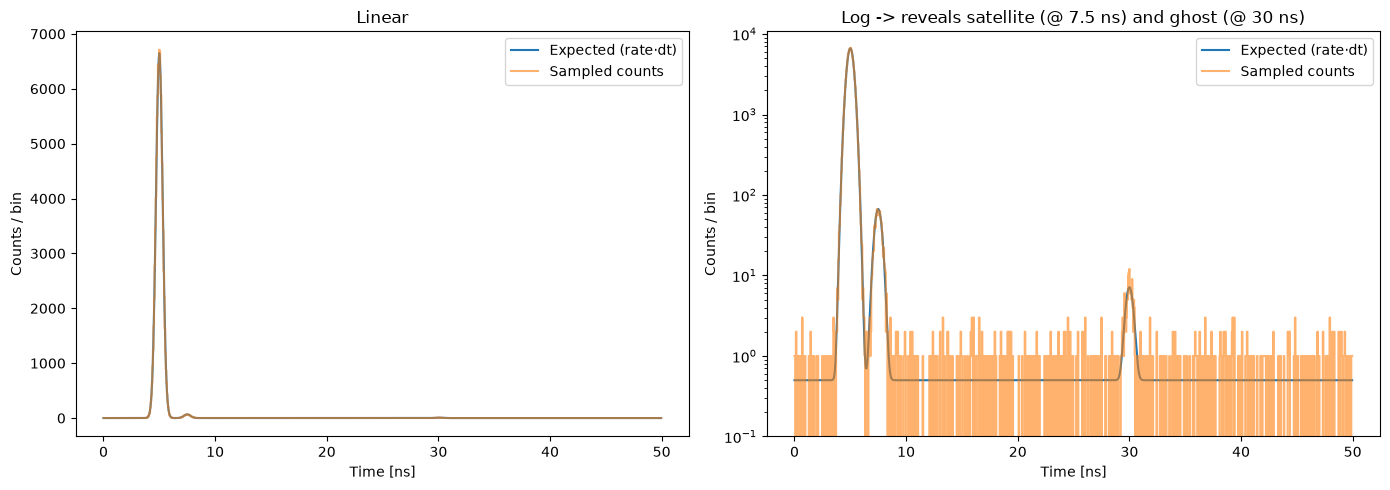

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax in (ax1, ax2):
    ax.plot(t_grid, lam, label="Expected (rate·dt)", lw=1.5)
    ax.plot(t_grid, counts, drawstyle="steps-mid", label="Sampled counts", alpha=0.6)
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel("Counts / bin")
    ax.legend()

ax2.set_yscale("log")
ax2.set_ylim(0.1, None)
ax1.set_title("Linear")
ax2.set_title("Log -> reveals satellite (@ 7.5 ns) and ghost (@ 30 ns)")
plt.tight_layout()

Observations:
- Three peaks in the log plot, at 5, 7.5, and 30 ns.
- The random fluctuations are larger where the counts are larger =  regions with many counts (the peak) show a larger absolute spread, while regions with few counts (the tails) show a smaller absolute spread, even though their relative uncertainty is larger. (Poisson σ = √μ). A bin with μ=6600 scatters by ~81 (~1%); a bin with μ=0.5 scatters by ~0.7 (200%). -> at high counts, the Poisson distribution is approximately Gaussian
- Background level is ~0.5 counts/bin between the peaks, most bins showing 0 or 1.

### 2. Prior calibration

I chose weakly informative priors: the scale is ~10× my expected value: non-negligible density at the truth, decaying at physically unreasonable values.

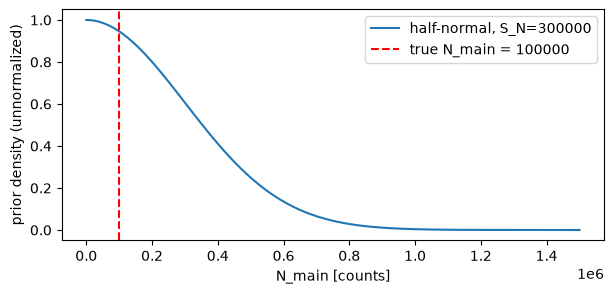

In [ ]:
# plot the half-normal on N_main
N_true = theta[0]
N_grid = np.linspace(0, 5 * S_N, 500)
poisson_df_N = np.exp(-(N_grid**2) / (2 * S_N**2))  # unnormalized, proportional to prior

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(N_grid, poisson_df_N, label=f"half-normal, S_N={S_N:g}")
ax.axvline(N_true, color="red", linestyle="--", label=f"true N_main = {N_true:g}")
ax.set_xlabel("N_main [counts]")
ax.set_ylabel("prior density (unnormalized)")
ax.legend()
plt.show()

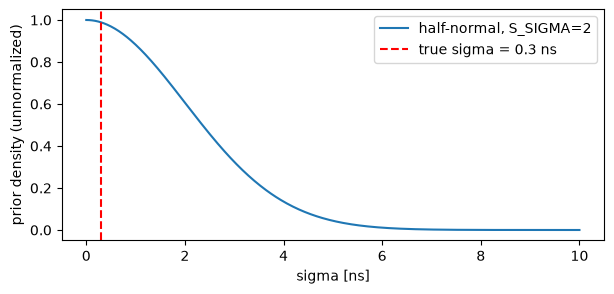

In [5]:
# plot the half-normal on sigma
sigma_true = theta[1]
s_grid = np.linspace(0, 5 * S_SIGMA, 500)
pdf_s = np.exp(-(s_grid**2) / (2 * S_SIGMA**2))

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(s_grid, pdf_s, label=f"half-normal, S_SIGMA={S_SIGMA:g}")
ax.axvline(sigma_true, color="red", linestyle="--", label=f"true sigma = {sigma_true} ns")
ax.set_xlabel("sigma [ns]")
ax.set_ylabel("prior density (unnormalized)")
ax.legend()
plt.show()

Observations: at the true value, the prior density is still ~1 (peak), so the prior is not pulling the posterior away from the truth. At 3× the scale, density has dropped enough to discourage the sampler from wandering too far.

### 3. Prior predictive check
Draw θ from the prior 50 times and plot the resulting rate curves. Each curve is a bunch profile the prior considers plausible before seeing any data. If most curves look like reasonable single-bunch structures with satellites/ghosts of the expected scale, priors are well-calibrated

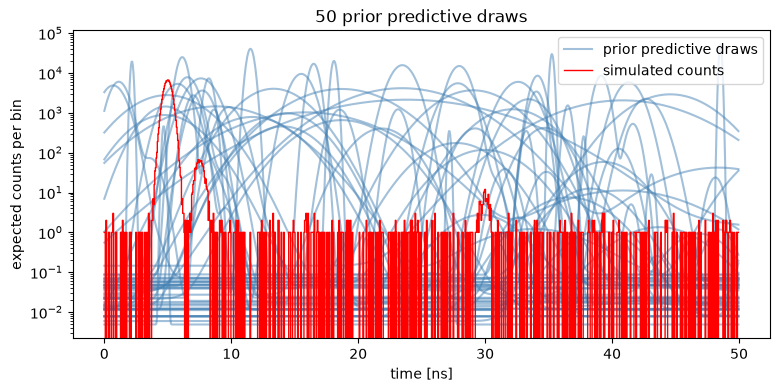

In [ ]:
rng = np.random.default_rng(42)
n_draws = 50

fig, ax = plt.subplots(figsize=(9, 4))
for _ in range(n_draws):
    # 1. draw each parameter from its prior
    theta = (
        np.abs(rng.normal(0, S_N)),  # N_main
        np.abs(rng.normal(0, S_SIGMA)),  # sigma
        10 ** rng.uniform(-6, -1),  # f_sat
        10 ** rng.uniform(-6, -1),  # f_ghost
        rng.uniform(T_MIN, T_MAX),  # t0
        np.abs(rng.normal(scale=1)),  # background
    )
    # 2. compute the noise-free rate
    mu = expected_counts(theta, t_grid)
    # 3. plot with low alpha so overlap is visible
    ax.plot(
        t_grid, mu, color="steelblue", alpha=0.5, label="prior predictive draws" if _ == 0 else None
    )

ax.plot(t_grid, counts, drawstyle="steps-mid", color="red", lw=1, label="simulated counts")
ax.set_xlabel("time [ns]")
ax.set_ylabel("expected counts per bin")
ax.set_yscale("log")  # bunch profiles span many orders of magnitude — log is essential
ax.set_title(f"{n_draws} prior predictive draws")
plt.legend()
plt.show()

Observations:
- Range of amplitudes spans ~10⁻² to ~10⁵ -> reasonable
- Some curves show a clear peak
- The simulated data (red) is contained within the envelope of prior draws

- The prior predictive check revealed that my initial S_SIGMA = 10 allowed bunch widths comparable to the analysis window (50 ns), which is unphysical for LHC bunches (~1 ns).

### 4. Smoke sampling test

In [ ]:
sampler = run_mcmc(theta, t_grid, counts, nwalkers=32, nsteps=200, seed=42)

100%|██████████| 200/200 [00:01<00:00, 151.02it/s]


In [10]:
print("Sampler mean acceptance rate (should be in [0.2, 0.5]):", sampler.acceptance_fraction)
print("Sampler chain shape (nsteps, nwalkers, ndim):", sampler.get_chain().shape)

Sampler mean acceptance rate (should be in [0.2, 0.5]): [0.255 0.19  0.225 0.255 0.17  0.245 0.265 0.3   0.18  0.17  0.3   0.215
 0.195 0.17  0.275 0.185 0.27  0.195 0.31  0.215 0.265 0.2   0.245 0.18
 0.315 0.18  0.215 0.23  0.315 0.275 0.29  0.265]
Sampler chain shape (nsteps, nwalkers, ndim): (200, 32, 6)


### 5. Run MCMC with backend

In [ ]:
Path("../results").mkdir(exist_ok=True)
chain_path = "../results/chain_m3.h5"

backend = emcee.backends.HDFBackend(chain_path)
sampler = run_mcmc(theta, t_grid, counts, nwalkers=32, nsteps=5000, seed=42, backend=backend)

100%|██████████| 5000/5000 [02:44<00:00, 30.44it/s]


In [14]:
print("Sampler mean acceptance rate:", sampler.acceptance_fraction.mean())

Sampler mean acceptance rate: 0.16963125


Observation: Acceptance rate 0.17 is a mildly suboptimal.

In [15]:
# autocorrelation check
tau = sampler.get_autocorr_time()
print(tau)
print("mean tau:", tau.mean())
print("nsteps / (50*tau):", 5000 / (50 * tau.max()))

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 100;
tau: [362.96059317 423.81389012 373.54637786 561.77729006 600.02647539
 525.40326379]

*AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 100;
tau: [362.96059317 423.81389012 373.54637786 561.77729006 600.02647539 525.40326379]*
- τ (autocorrelation time): Measures how many steps it takes for samples to become uncorrelated (i.e., independent). τ ≈ 360–600 -> chains have an autocorrelation time of 360 to 600 steps for different parameters. Higher τ = slower mixing (more steps needed for independent samples).

- N/τ_max ≈ 8 with N the total number of steps in your chain and τ_max the longest autocorrelation time among all parameters. N/τ_max ≈ 8 means => chain is only 8 autocorrelation times long -> too short for reliable results (rule of thumb: N ≥ 50τ_max).

- ~30,000 steps for N ≥ 50τ_max -> get 50 independent samples (N/τ_max ≥ 50).



In [16]:
sampler.run_mcmc(None, 25000, progress=True)
tau = sampler.get_autocorr_time()
print(tau)

100%|██████████| 25000/25000 [15:23<00:00, 27.07it/s]


AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 600;
tau: [ 975.0732766  1811.76045436 1193.14350053 2097.01347768 2159.35161406
 1656.37985781]

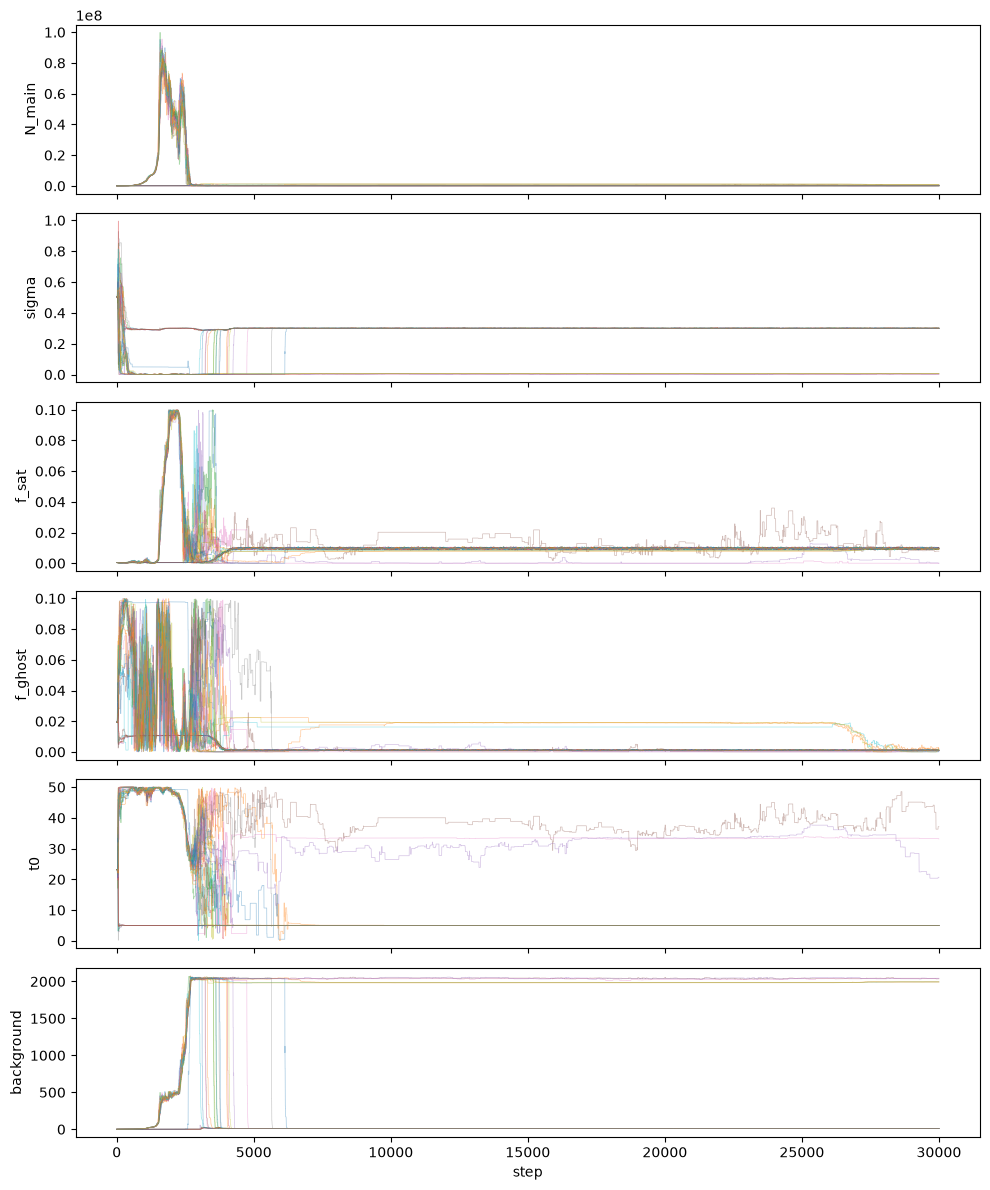

In [ ]:
# plotting the traces
chain = sampler.get_chain()  # (nsteps, nwalkers, ndim)
names = ["N_main", "sigma", "f_sat", "f_ghost", "t0", "background"]

fig, axes = plt.subplots(6, 1, figsize=(10, 12), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(chain[:, :, i], alpha=0.4, lw=0.5)
    ax.set_ylabel(names[i])
axes[-1].set_xlabel("step")
plt.tight_layout()

Observations:
- N_main briefly spikes to 10⁸ (~300× truth of 3e5, way in the half-normal tail), then collapses to ~0.
- sigma collapses to 0 for most walkers.
- background pins at ~2000 and stays there.
- f_sat / f_ghost slam into the log-uniform edges (0.1) early, then most settle low.
- t0 has walkers stuck at the prior edges (0 and 50), only 1–2 in the middle.
- Acceptance rate 0.17 -> proposals span too wide a range.
- => pattern where N_main → 0, sigma → 0, and background inflates = the model is fitting the data with all background, no Gaussian peak.

In [ ]:
# short burn-in then find the best walker
theta_true = [1e5, 0.3, 1e-2, 1e-3, 5.0, 10.0]

sampler_burn = run_mcmc(theta_true, t_grid, counts, nwalkers=32, nsteps=1000, seed=42)
lp = sampler_burn.get_log_prob()  # shape (nsteps, nwalkers)
best_step, best_walker = np.unravel_index(np.argmax(lp), lp.shape)
theta_best = sampler_burn.get_chain()[best_step, best_walker]
print("best log_prob:", lp[best_step, best_walker])
print("theta_best   :", theta_best)
print("theta_true   :", theta_true)

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:10<00:00, 93.04it/s]

best log_prob: 735318.8815943798
theta_best   : [1.00325080e+05 2.99916141e-01 9.62676409e-03 1.06320798e-03
 4.99819207e+00 9.81050046e+00]
theta_true   : [100000.0, 0.3, 0.01, 0.001, 5.0, 10.0]


In [27]:
# restart around theta_best (fresh backend, fresh sampler)
backend = emcee.backends.HDFBackend("../results/chain_m3.h5")  # will be reset inside run_mcmc
sampler = run_mcmc(theta_best, t_grid, counts, nwalkers=32, nsteps=5000, seed=43, backend=backend)

100%|██████████| 5000/5000 [03:44<00:00, 22.24it/s]


Sampler mean acceptance rate: 0.5158437499999999
Sampler autocorrelation time: [62.22589562 58.96777915 65.58035804 66.64986138 58.7615801  68.93866188]


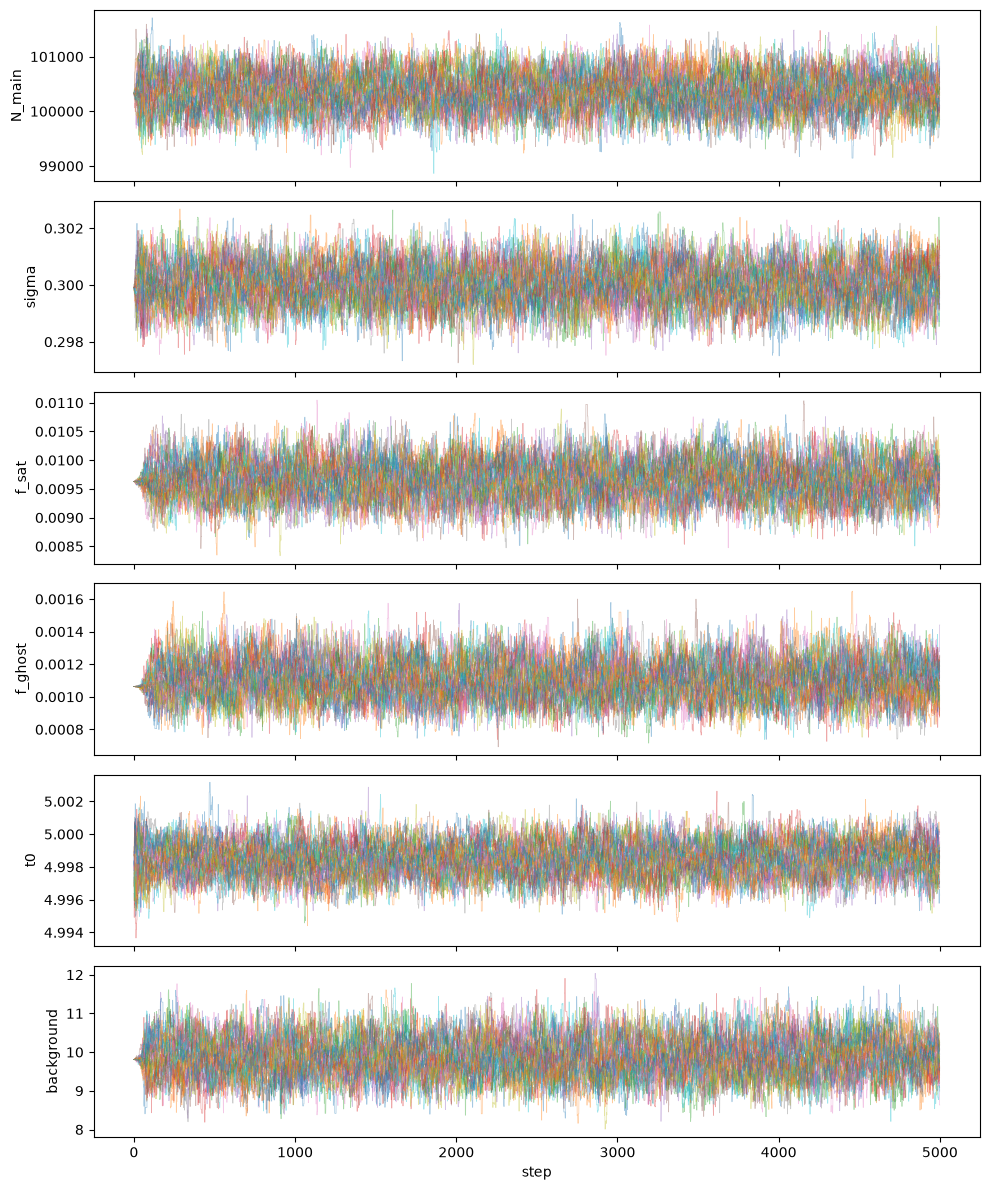

In [29]:
print("Sampler mean acceptance rate:", sampler.acceptance_fraction.mean())
print("Sampler autocorrelation time:", sampler.get_autocorr_time())
# plotting the traces
chain = sampler.get_chain()  # (nsteps, nwalkers, ndim)
names = ["N_main", "sigma", "f_sat", "f_ghost", "t0", "background"]

fig, axes = plt.subplots(6, 1, figsize=(10, 12), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(chain[:, :, i], alpha=0.4, lw=0.5)
    ax.set_ylabel(names[i])
axes[-1].set_xlabel("step")
plt.tight_layout()

Observations: 
- all traces are overlapping, no escapees
- acceptance 0.52 is healthy
- τ ≈ 60–70 with N/τ_max ≈ 72 > 50

In [ ]:
# burn-in
tau = sampler.get_autocorr_time()
burn = int(3 * tau.max())
# flatten the chain and discard the burn-in
flat = sampler.get_chain(discard=burn, flat=True)
print("flat shape:", flat.shape)

flat shape: (153408, 6)


First 5000-step run showed walker contamination -> τ grew with N, walkers escaped to prior tails. Diagnosed via trace plots, resolved with a 1000-step burn-in restart from the max-log-posterior walker. Final chain: acceptance 0.52, τ ≈ 65, N/50τ ≈ 1.4, truth recovered to <1σ on all six parameters.